# Experiment results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Resampling experiment

In [2]:
data = pd.read_csv('results.csv')
data = data.loc[data['exp_group'] == 1]

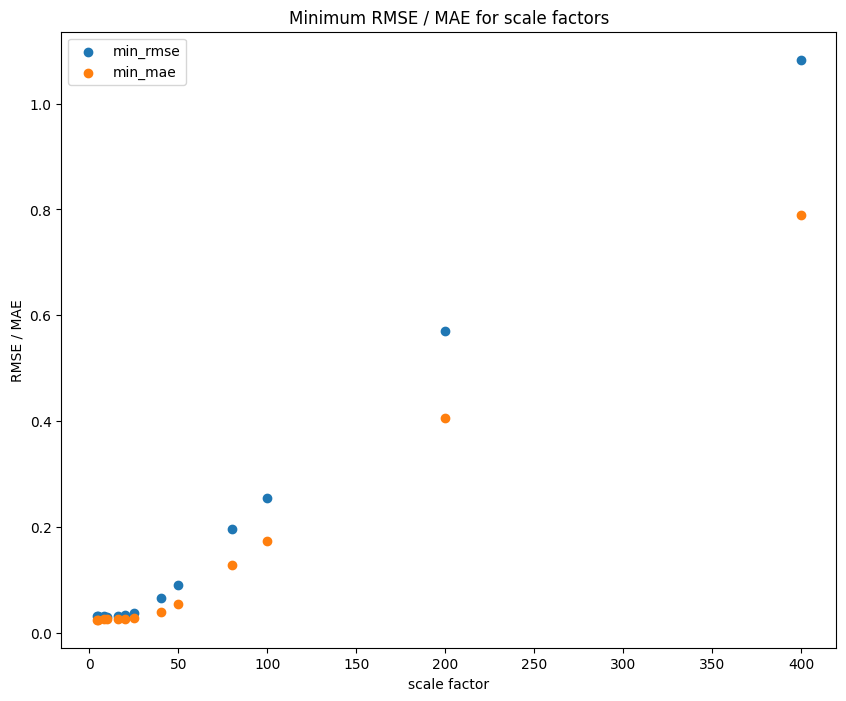

In [3]:
min_rmses = dict()
min_maes = dict()
for scale_factor in data['scale_factor'].unique():
    min_rmse_exp = data.loc[data['scale_factor'] == scale_factor]['rmse'].min(skipna=True)
    min_rmses[scale_factor] = min_rmse_exp
    min_mae_exp = data.loc[data['scale_factor'] == scale_factor]['mae'].min(skipna=True)
    min_maes[scale_factor] = min_mae_exp

plt.figure(figsize = (10,8))
plt.scatter(min_rmses.keys(), min_rmses.values(), label='min_rmse')
plt.scatter(min_maes.keys(), min_maes.values(), label='min_mae')
plt.title('Minimum RMSE / MAE for scale factors')
plt.xlabel('scale factor')
plt.ylabel('RMSE / MAE')
plt.legend()

plt.show()

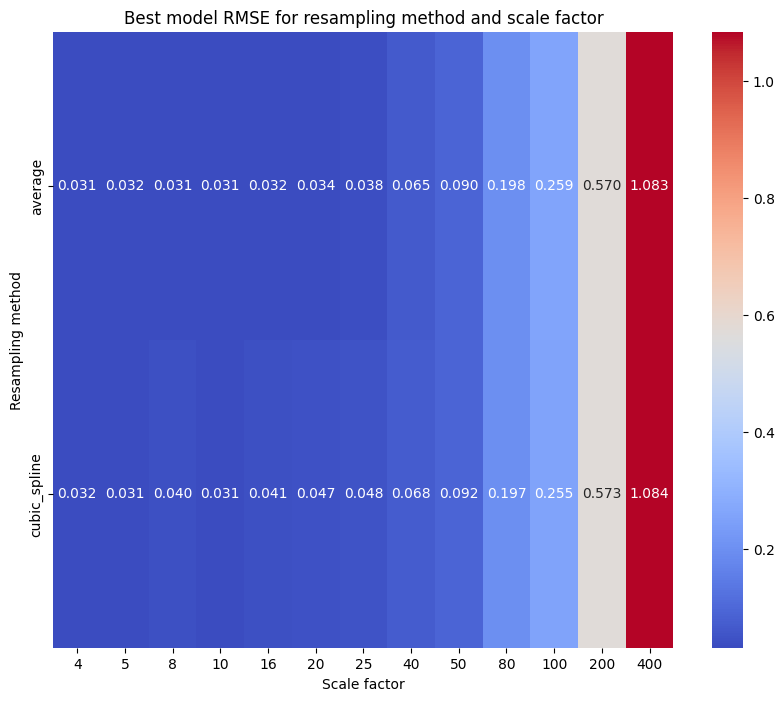

In [4]:
resampling_scale_factor = np.zeros((len(data['resampling'].unique()), len(data['scale_factor'].unique())))

for i, resampling in enumerate(data['resampling'].unique()):
    for j, scale_factor in enumerate(data['scale_factor'].unique()):
        min_rmse_exp = data.loc[(data['resampling'] == resampling) & (data['scale_factor'] == scale_factor)]['rmse'].min(skipna=True)
        resampling_scale_factor[i][j] = min_rmse_exp
plt.figure(figsize = (10,8))
sns.heatmap(resampling_scale_factor, cmap='coolwarm', annot=True, fmt='.3f', yticklabels=data['resampling'].unique(), xticklabels=data['scale_factor'].unique())
plt.title('Best model RMSE for resampling method and scale factor')
plt.ylabel('Resampling method')
plt.xlabel('Scale factor')
plt.show()

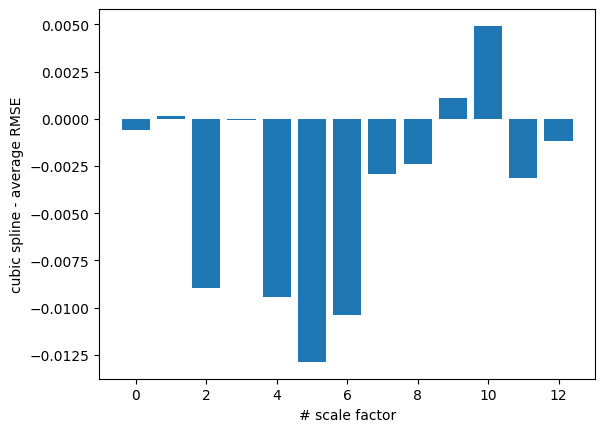

In [5]:
diff = resampling_scale_factor[0] - resampling_scale_factor[1]
plt.bar(x=range(len(diff)), height=diff)
plt.ylabel('cubic spline - average RMSE')
plt.xlabel('# scale factor')
plt.show()

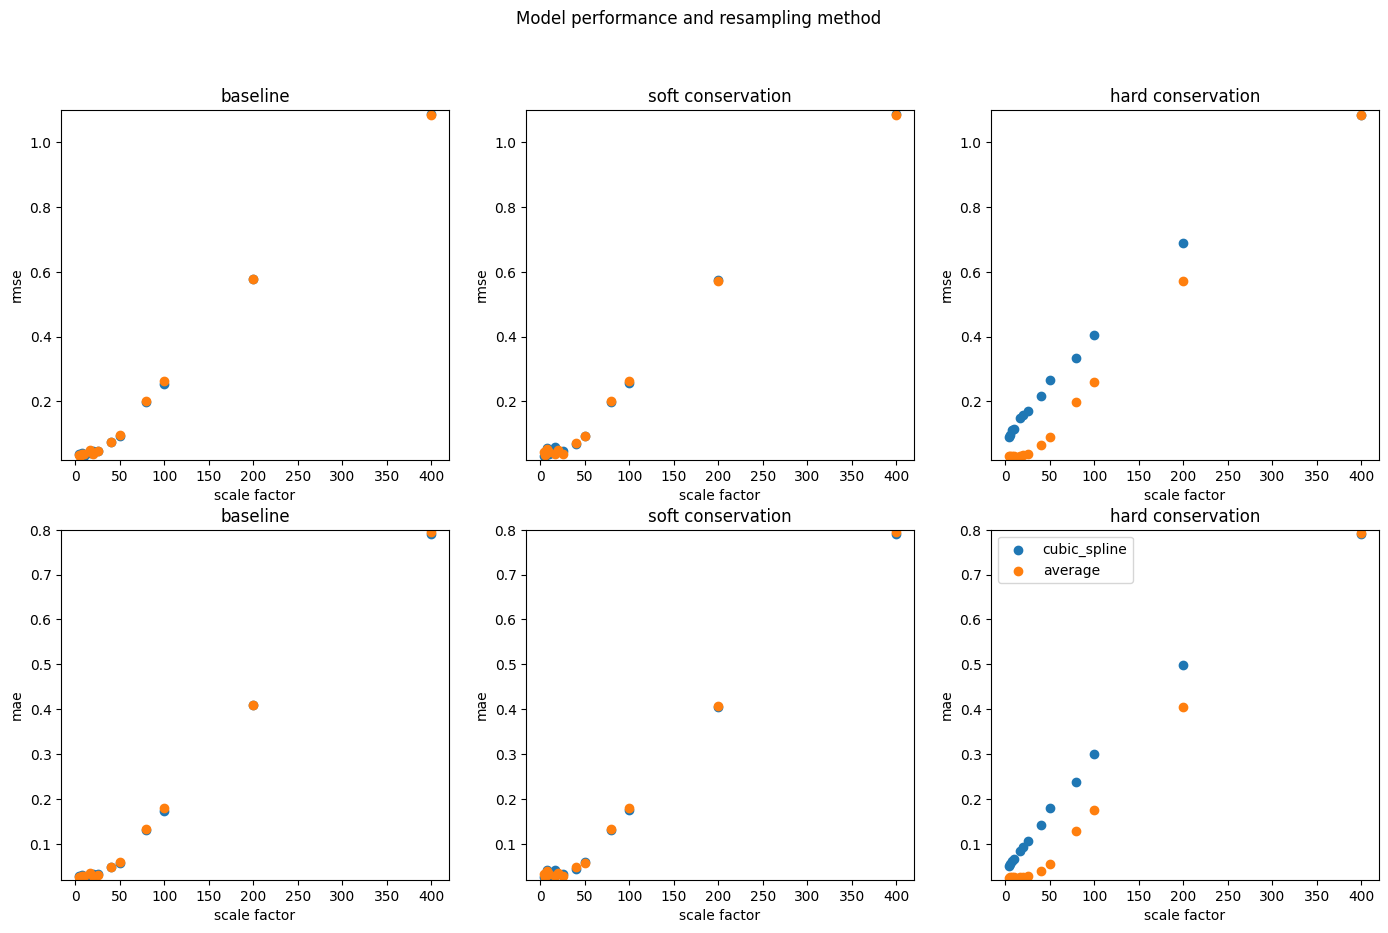

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17,10))
lims = [[0.02, 1.1], [0.02, 0.8]]
titles = ['baseline', 'soft conservation', 'hard conservation']
for i, metric in enumerate(['rmse', 'mae']):

    for j, group in enumerate([1, 2, 12]):
        exps = data[data['group'] == group]
        axs[i, j].scatter(exps.loc[exps['resampling'] == 'cubic_spline', 'scale_factor'], exps.loc[exps['resampling'] == 'cubic_spline', metric], label='cubic_spline')
        axs[i, j].scatter(exps.loc[exps['resampling'] == 'average', 'scale_factor'], exps.loc[exps['resampling'] == 'average', metric], label='average')
        axs[i, j].set_xlabel('scale factor')
        axs[i, j].set_ylabel(metric)
        axs[i, j].set_ylim(lims[i])
        axs[i, j].set_title(titles[j])
plt.legend(loc='upper left')
plt.suptitle('Model performance and resampling method')
plt.show()

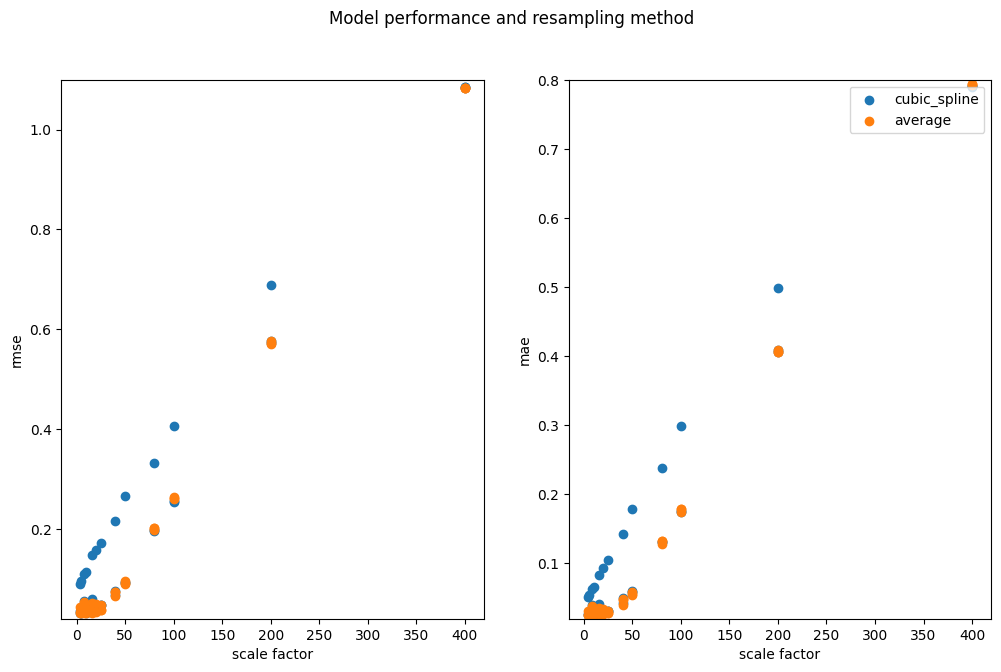

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,7))
lims = [[0.02, 1.1], [0.02, 0.8]]
for i, metric in enumerate(['rmse', 'mae']):
    exps = data.copy()
    axs[i].scatter(exps.loc[exps['resampling'] == 'cubic_spline', 'scale_factor'], exps.loc[exps['resampling'] == 'cubic_spline', metric], label='cubic_spline')
    axs[i].scatter(exps.loc[exps['resampling'] == 'average', 'scale_factor'], exps.loc[exps['resampling'] == 'average', metric], label='average')
    axs[i].set_xlabel('scale factor')
    axs[i].set_ylabel(metric)
    axs[i].set_ylim(lims[i])
plt.legend()
plt.suptitle('Model performance and resampling method')
plt.show()

In [8]:
best_rmses = dict()
for resampling in data['resampling'].unique():
    df1 = data.loc[data['resampling'] == resampling]
    for scale_factor in df1['scale_factor'].unique():
        df2 = df1.loc[df1['scale_factor'] == scale_factor]

        for group in [1, 2, 12]:
            df3 = df2.loc[df2['group'] == group]
            best_rmses[(resampling, scale_factor, group)] = min(df3['rmse'])

In [9]:
ratios = dict()
for (resampling, scale_factor, group), rmse in best_rmses.items():
    ratios[(resampling, scale_factor, group)] =  best_rmses[(resampling, scale_factor, group)] / best_rmses[(resampling, scale_factor, 1)]
ratios

{('average', np.int64(4), 1): 1.0,
 ('average', np.int64(4), 2): 1.280727923627685,
 ('average', np.int64(4), 12): 0.9307875894988066,
 ('average', np.int64(5), 1): 1.0,
 ('average', np.int64(5), 2): 1.0820139328689045,
 ('average', np.int64(5), 12): 1.0281823939202028,
 ('average', np.int64(8), 1): 1.0,
 ('average', np.int64(8), 2): 1.4716775599128538,
 ('average', np.int64(8), 12): 0.8518518518518519,
 ('average', np.int64(10), 1): 1.0,
 ('average', np.int64(10), 2): 1.2069716775599126,
 ('average', np.int64(10), 12): 0.838235294117647,
 ('average', np.int64(16), 1): 1.0,
 ('average', np.int64(16), 2): 0.7423409269442263,
 ('average', np.int64(16), 12): 0.6270620581304006,
 ('average', np.int64(20), 1): 1.0,
 ('average', np.int64(20), 2): 1.3450276243093922,
 ('average', np.int64(20), 12): 0.9328729281767956,
 ('average', np.int64(25), 1): 1.0,
 ('average', np.int64(25), 2): 0.8072983354673496,
 ('average', np.int64(25), 12): 0.8049509176269739,
 ('average', np.int64(40), 1): 1.0,
 (

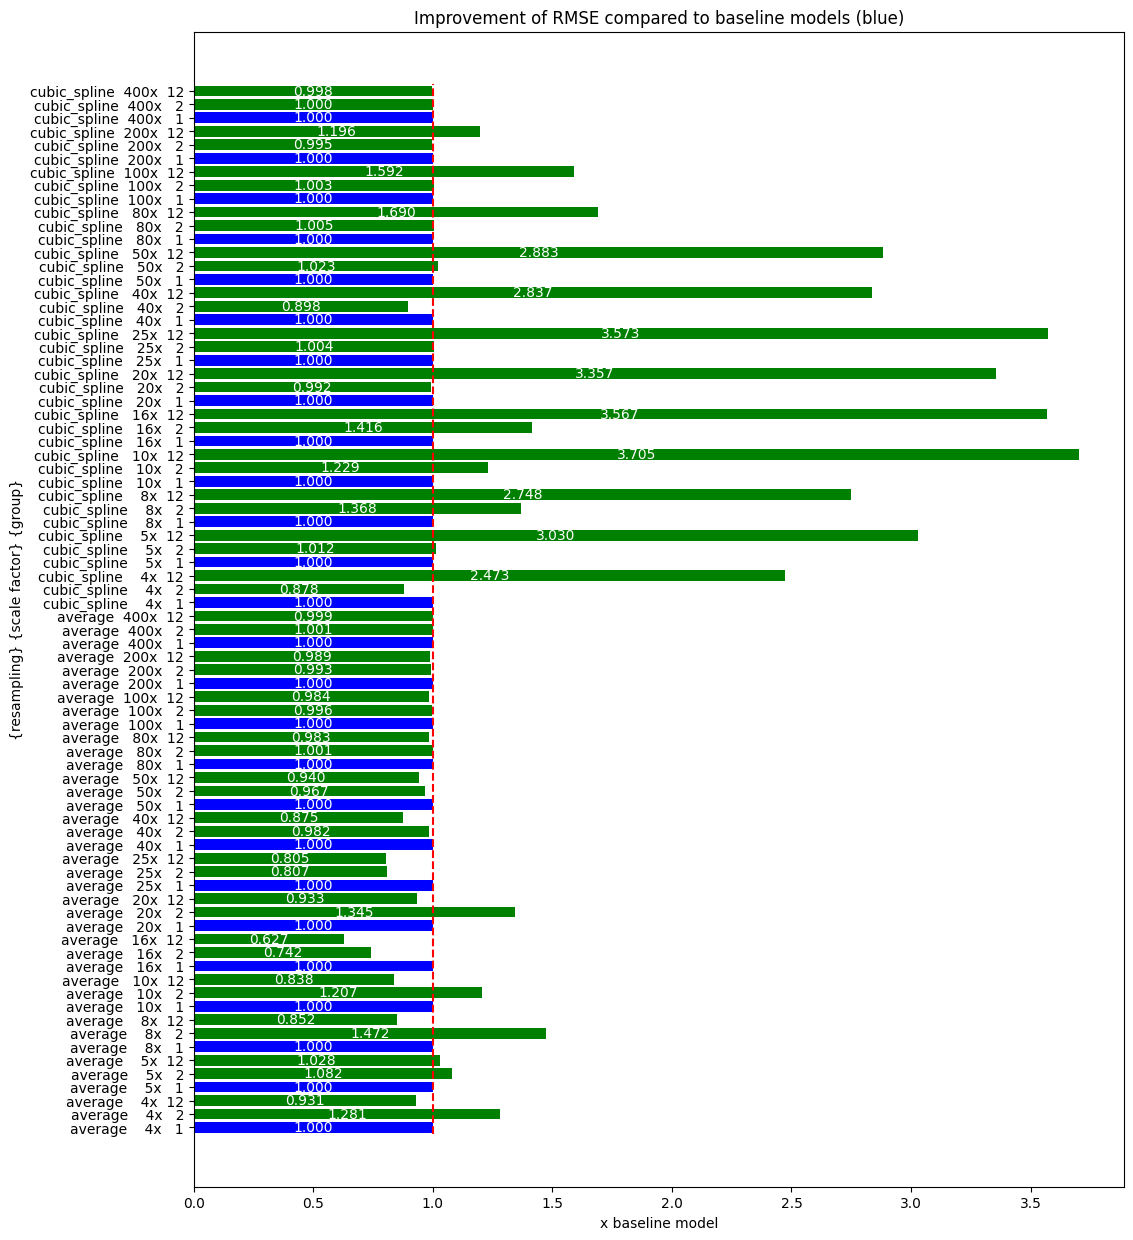

In [10]:
fig, ax = plt.subplots(figsize=(12,15))
b = ax.barh(width=[x for x in ratios.values()], y=[f'{x[0]} {x[1]:4}x {x[2]:3}' for x in ratios.keys()], color=['blue' if i % 3 == 0 else 'green' for i, _ in enumerate(ratios.keys())])
ax.plot([1, 1], [-0.5, len(ratios.keys()) - 0.5], linestyle='--', color='red')
ax.bar_label(b, fmt='%.3f', label_type='center', color='white')
ax.title.set_text('Improvement of RMSE compared to baseline models (blue)')
ax.set_ylabel('{resampling} {scale factor} {group}')
ax.set_xlabel('x baseline model')
plt.show()

In [11]:
avg = data[data['resampling'] == 'average']
scale_factors = sorted(avg['scale_factor'].unique())
groups = sorted(avg['group'].unique())

hm_avg = np.zeros((len(groups), len(scale_factors)))
for i, group in enumerate(groups):
    for j, scale_factor in enumerate(scale_factors):
        hm_avg[i, j] = avg.loc[(avg['group'] == group) & (avg['scale_factor'] == scale_factor), 'rmse']

cs = data[data['resampling'] == 'cubic_spline']

hm_cs = np.zeros((len(groups), len(scale_factors)))
for i, group in enumerate(groups):
    for j, scale_factor in enumerate(scale_factors):
        hm_cs[i, j] = cs.loc[(cs['group'] == group) & (cs['scale_factor'] == scale_factor), 'rmse']


/tmp/ipykernel_26609/4138480352.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hm_avg[i, j] = avg.loc[(avg['group'] == group) & (avg['scale_factor'] == scale_factor), 'rmse']
/tmp/ipykernel_26609/4138480352.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hm_cs[i, j] = cs.loc[(cs['group'] == group) & (cs['scale_factor'] == scale_factor), 'rmse']


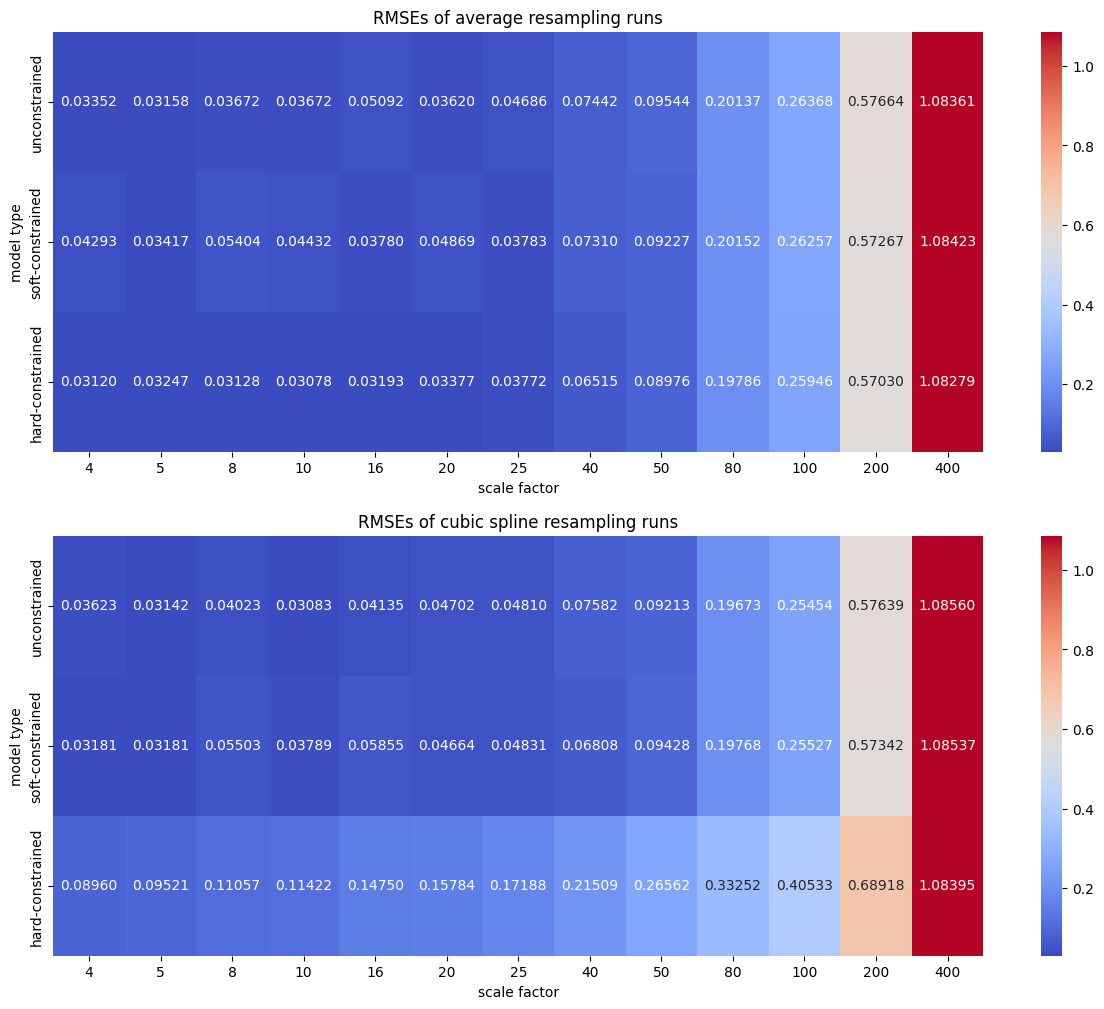

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(15, 12))

vmin = min(hm_cs.min(), hm_avg.min())
vmax = max(hm_cs.max(), hm_avg.max())

sns.heatmap(hm_avg, xticklabels=scale_factors,
            yticklabels=['unconstrained', 'soft-constrained', 'hard-constrained'],
            annot=True, fmt='.5f', cmap='coolwarm', vmin=vmin, vmax=vmax,
            ax = axs[0])

axs[0].set_xlabel('scale factor')
axs[0].set_ylabel('model type')
axs[0].set_title('RMSEs of average resampling runs')

sns.heatmap(hm_cs, xticklabels=scale_factors,
            yticklabels=['unconstrained', 'soft-constrained', 'hard-constrained'],
            annot=True, fmt='.5f', cmap='coolwarm', vmin=vmin, vmax=vmax,
            ax = axs[1])

axs[1].set_xlabel('scale factor')
axs[1].set_ylabel('model type')
axs[1].set_title('RMSEs of cubic spline resampling runs')

plt.show()

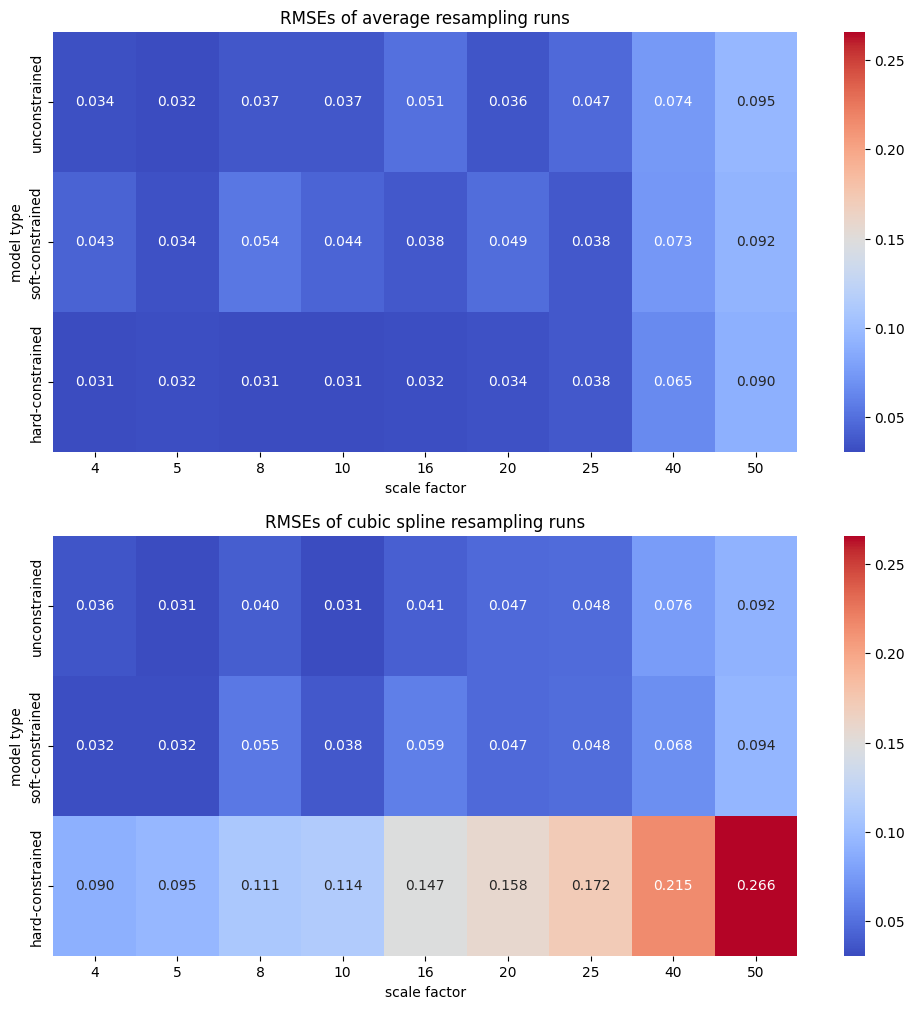

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

vmin = min(hm_cs[:, :9].min(), hm_avg[:, :9].min())
vmax = max(hm_cs[:, :9].max(), hm_avg[:, :9].max())

sns.heatmap(hm_avg[:, :9], xticklabels=scale_factors[:9],
            yticklabels=['unconstrained', 'soft-constrained', 'hard-constrained'],
            annot=True, fmt='.3f', cmap='coolwarm', vmin=vmin, vmax=vmax,
            ax = axs[0])

axs[0].set_xlabel('scale factor')
axs[0].set_ylabel('model type')
axs[0].set_title('RMSEs of average resampling runs')

sns.heatmap(hm_cs[:, :9], xticklabels=scale_factors[:9],
            yticklabels=['unconstrained', 'soft-constrained', 'hard-constrained'],
            annot=True, fmt='.3f', cmap='coolwarm', vmin = vmin, vmax=vmax,
            ax = axs[1])

axs[1].set_xlabel('scale factor')
axs[1].set_ylabel('model type')
axs[1].set_title('RMSEs of cubic spline resampling runs')

plt.show()

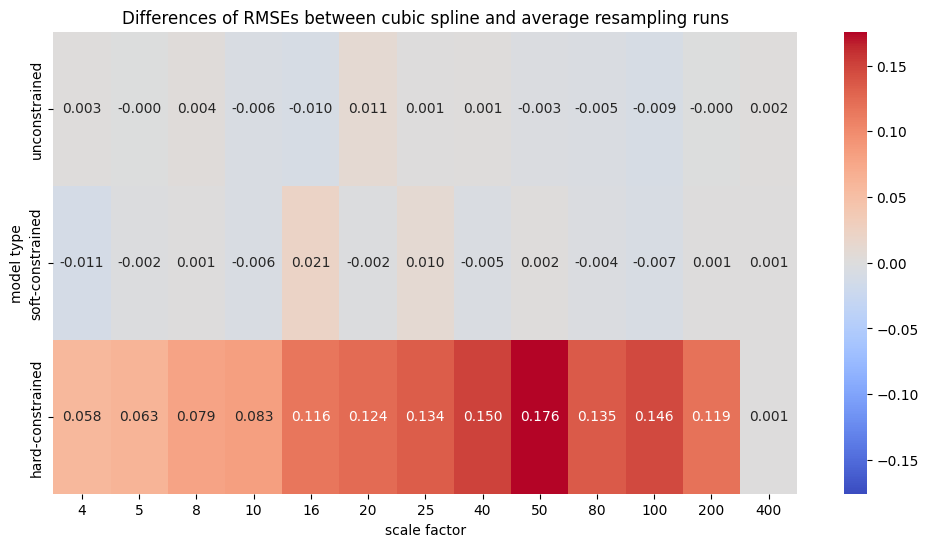

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

hm_diff = hm_cs - hm_avg

vmax = np.abs(hm_diff).max()
vmin = -vmax

sns.heatmap(hm_diff, xticklabels=scale_factors,
            yticklabels=['unconstrained', 'soft-constrained', 'hard-constrained'],
            annot=True, fmt='.3f', cmap='coolwarm', vmin=vmin, vmax=vmax,
            ax = ax)

ax.set_xlabel('scale factor')
ax.set_ylabel('model type')
ax.set_title('Differences of RMSEs between cubic spline and average resampling runs')

plt.show()

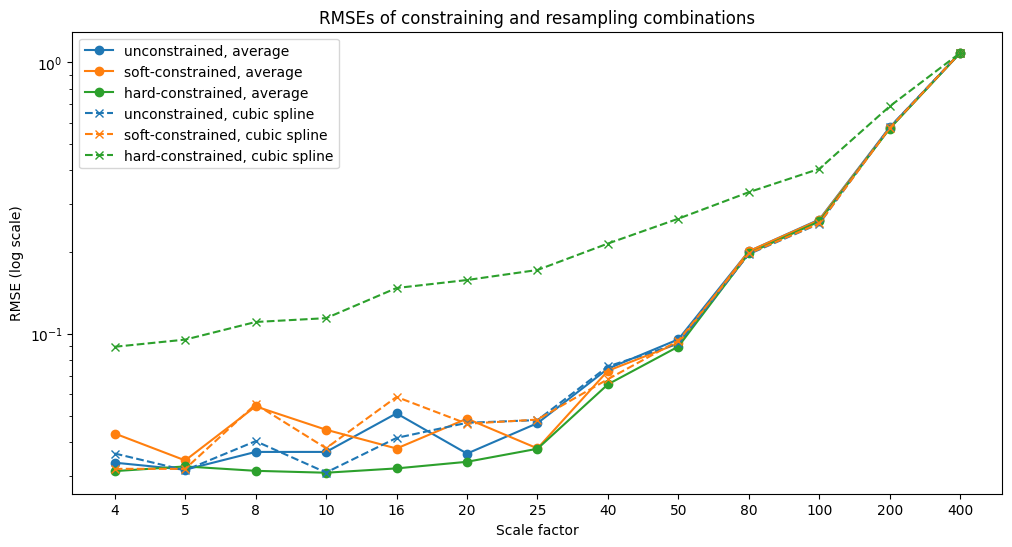

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(hm_avg[0], color='tab:blue', label='unconstrained, average', marker='o')
ax.plot(hm_avg[1], color='tab:orange', label='soft-constrained, average', marker='o')
ax.plot(hm_avg[2], color='tab:green', label='hard-constrained, average', marker='o')

ax.plot(hm_cs[0], color='tab:blue', label='unconstrained, cubic spline', marker='x', linestyle='dashed')
ax.plot(hm_cs[1], color='tab:orange', label='soft-constrained, cubic spline', marker='x', linestyle='dashed')
ax.plot(hm_cs[2], color='tab:green', label='hard-constrained, cubic spline', marker='x', linestyle='dashed')

ax.legend()
ax.set_yscale('log')
ax.set_xticks(range(len(scale_factors)), scale_factors)
ax.set_xlabel('Scale factor')
ax.set_ylabel('RMSE (log scale)')

ax.set_title('RMSEs of constraining and resampling combinations')

plt.show()

fig.savefig('images/resampling_plot.pdf', bbox_inches='tight', dpi=300)

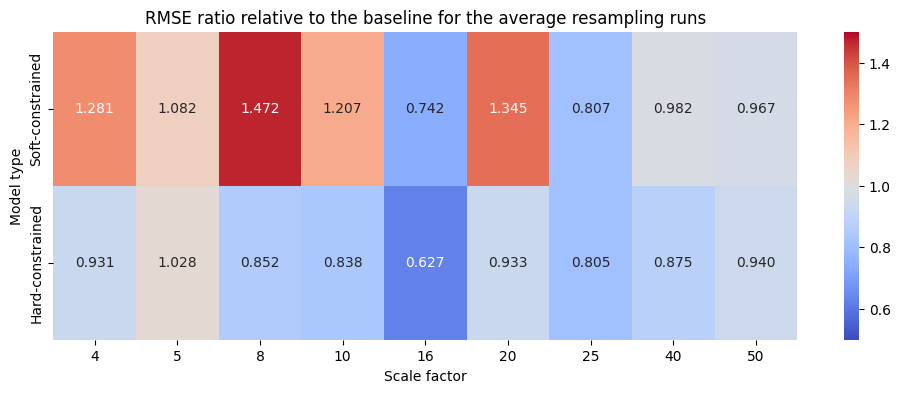

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.heatmap((hm_avg / hm_avg[0])[1:, :9], xticklabels=scale_factors[:9], yticklabels=['Soft-constrained', 'Hard-constrained'], annot=True, fmt='.3f', cmap='coolwarm', vmin=0.5, vmax=1.5, ax = ax)

ax.set_xlabel('Scale factor')
ax.set_ylabel('Model type')
ax.set_title('RMSE ratio relative to the baseline for the average resampling runs')
plt.show()

fig.savefig('images/resampling_rel_avg_9.pdf', bbox_inches='tight', dpi=300)

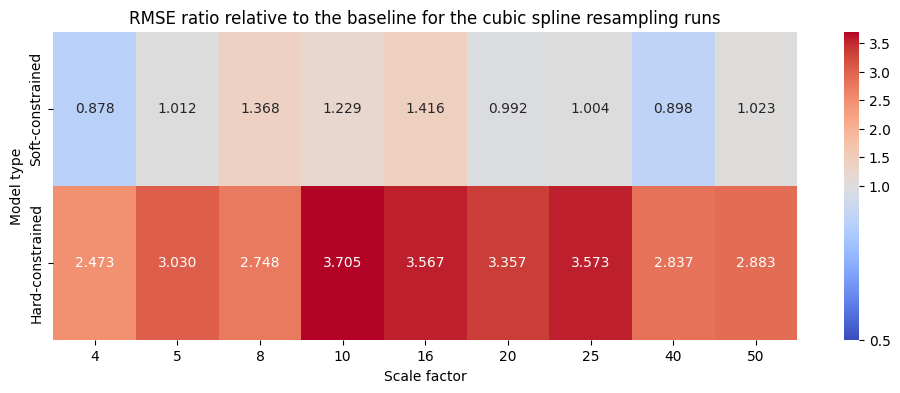

In [17]:
import matplotlib.colors as colors


fig, ax = plt.subplots(1, 1, figsize=(12, 4))

vmin = 0.5
vcenter = 1
vmax = (hm_cs / hm_cs[0])[1:, :9].max()

norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

sns.heatmap((hm_cs / hm_cs[0])[1:, :9], xticklabels=scale_factors[:9], yticklabels=['Soft-constrained', 'Hard-constrained'], annot=True, fmt='.3f', cmap='coolwarm', ax = ax, norm = norm)

ax.set_xlabel('Scale factor')
ax.set_ylabel('Model type')
ax.set_title('RMSE ratio relative to the baseline for the cubic spline resampling runs')
plt.show()
fig.savefig('images/resampling_rel_cs_9.pdf', bbox_inches='tight', dpi=300)

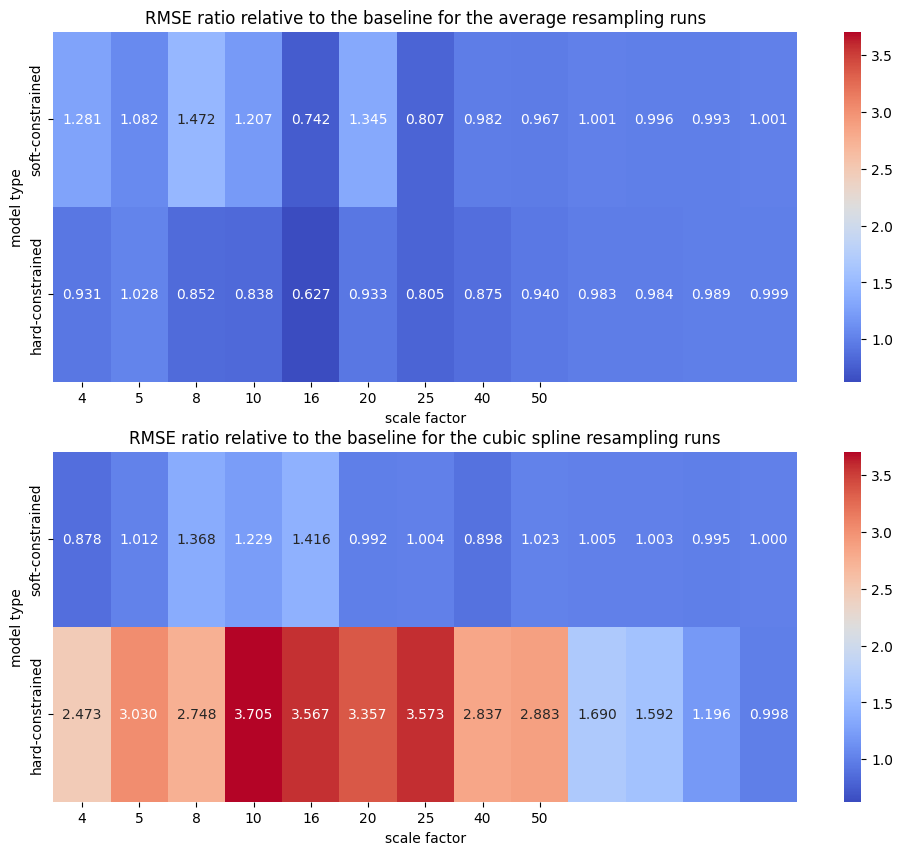

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

hm_cs_rel = hm_cs[1:] / hm_cs[0]
hm_avg_rel = hm_avg[1:] / hm_avg[0]

vmin = min(hm_cs_rel.min() , hm_avg_rel.min())
vmax = max(hm_cs_rel.max(), hm_avg_rel.max())

sns.heatmap(hm_avg_rel, xticklabels=scale_factors[:9],
            yticklabels=['soft-constrained', 'hard-constrained'],
            annot=True, fmt='.3f', cmap='coolwarm', vmin=vmin, vmax=vmax,
            ax = axs[0])

axs[0].set_xlabel('scale factor')
axs[0].set_ylabel('model type')
axs[0].set_title('RMSE ratio relative to the baseline for the average resampling runs')

sns.heatmap(hm_cs_rel, xticklabels=scale_factors[:9],
            yticklabels=['soft-constrained', 'hard-constrained'],
            annot=True, fmt='.3f', cmap='coolwarm', vmin = vmin, vmax=vmax,
            ax = axs[1])

axs[1].set_xlabel('scale factor')
axs[1].set_ylabel('model type')
axs[1].set_title('RMSE ratio relative to the baseline for the cubic spline resampling runs')

plt.show()

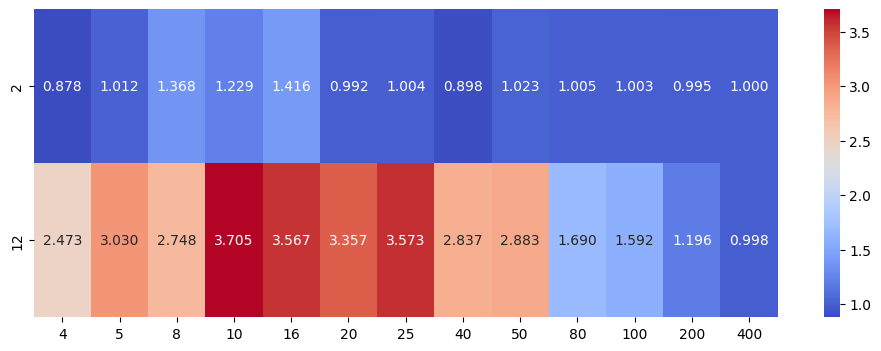

In [19]:
plt.figure(figsize=(12, 4))
sns.heatmap(hm_cs[1:] / hm_cs[0], xticklabels=scale_factors, yticklabels=groups[1:], annot=True, fmt='.3f', cmap='coolwarm')
plt.show()

## Sizes experiment

In [20]:
data = pd.read_csv('results.csv')
data = data.loc[data['exp_group'] == 5]

In [21]:
def make_matrices(df):
    matrices = np.zeros([3, len(df['features'].unique()), len(df['residual_blocks'].unique())])

    for i, group in enumerate([1, 2, 12]):
        temp = df.loc[df['group'] == group]
        for j, features in enumerate(sorted(temp['features'].unique())):
            for k, residual_blocks in enumerate(sorted(temp['residual_blocks'].unique())):
                matrices[i][j][k] = temp.loc[(temp['features'] == features) & (temp['residual_blocks'] == residual_blocks)]['rmse'].min()

    return matrices

rmses = make_matrices(data)

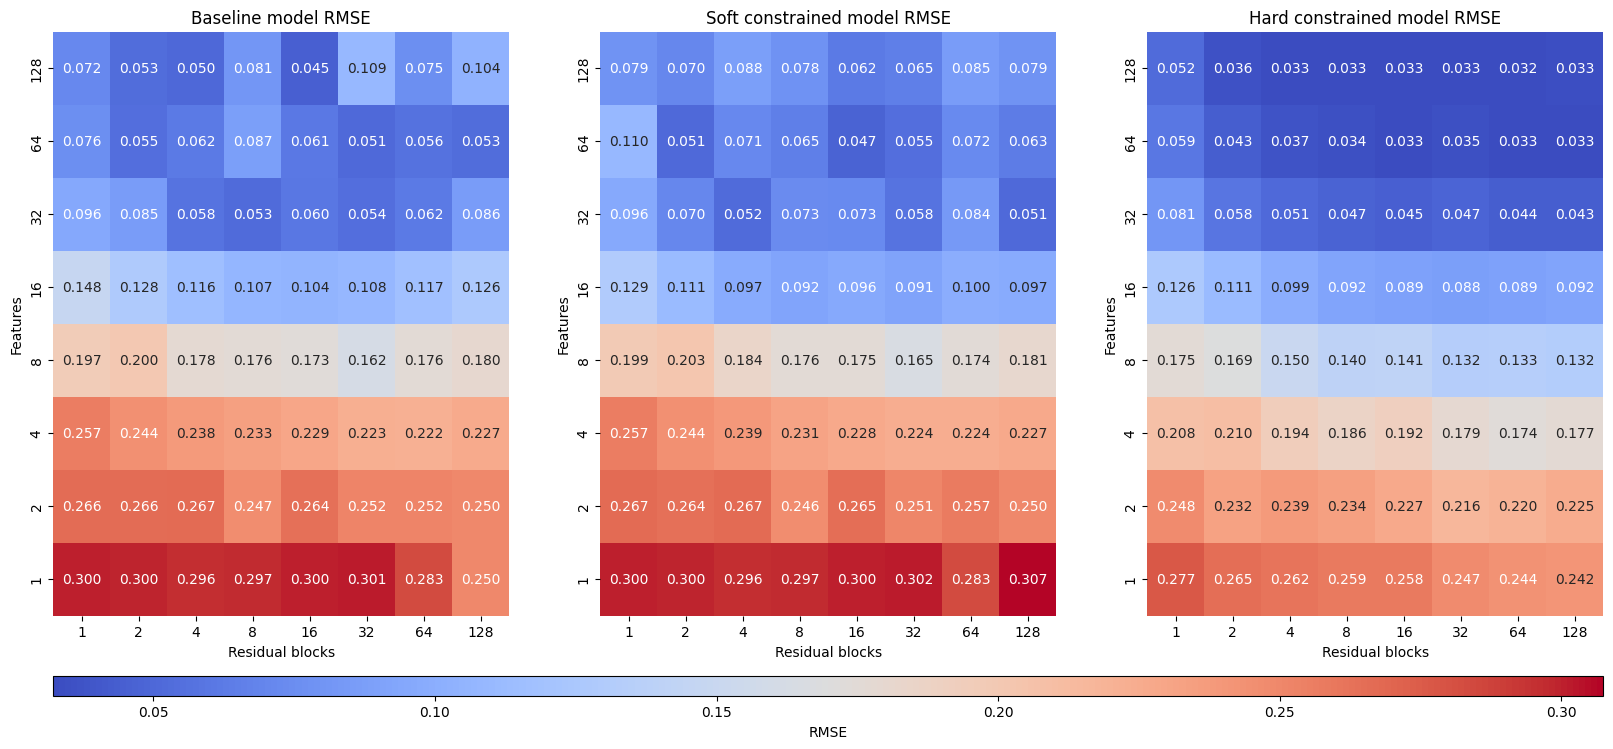

In [22]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize = (20,8))

vmin, vmax = np.min(rmses), np.max(rmses)

titles = ['Baseline model RMSE', 'Soft constrained model RMSE', 'Hard constrained model RMSE']
for i in range(3):
    axs[i].set_title(titles[i])
    sns.heatmap(rmses[i],
                xticklabels=sorted(data['residual_blocks'].unique()),
                yticklabels=sorted(data['features'].unique()),
                fmt='.3f', annot=True,
                vmin=vmin, vmax=vmax, cbar = False,
                cmap='coolwarm', ax=axs[i])
    axs[i].set_xlabel('Residual blocks')
    axs[i].set_ylabel('Features')
    axs[i].invert_yaxis()

fig.subplots_adjust(bottom=0.15)

left = axs[0].get_position().x0
width = axs[2].get_position().x1 - left

cbar_ax = fig.add_axes([left, 0.05, width, 0.025])
fig.colorbar(axs[0].collections[0], cax = cbar_ax, orientation='horizontal', label='RMSE')

plt.show()

fig.savefig('images/sizes.pdf', bbox_inches='tight', dpi = 300)

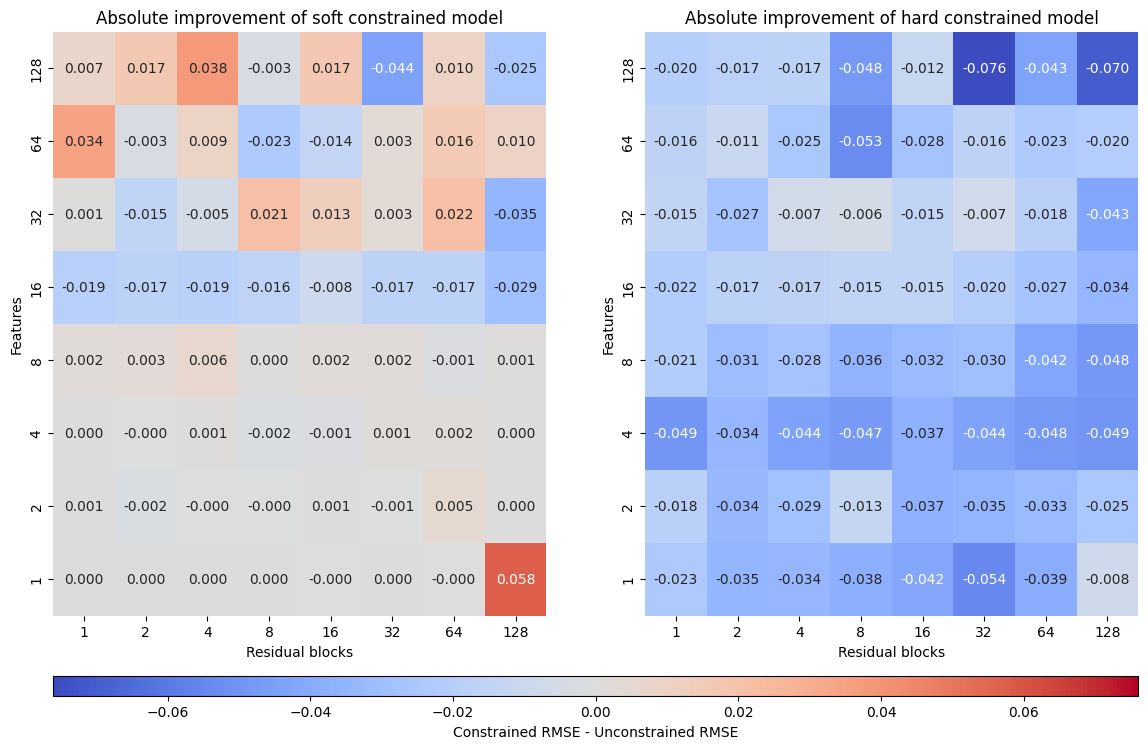

In [23]:
soft_diff = rmses[1] - rmses[0]
hard_diff = rmses[2] - rmses[0]

diffs = np.stack([soft_diff, hard_diff])

fig, axs = plt.subplots(nrows=1, ncols=2, figsize = (14,8))

abs_max = np.abs(diffs).max()

titles = ['Absolute improvement of soft constrained model', 'Absolute improvement of hard constrained model']
for i in range(2):
    axs[i].set_title(titles[i])
    sns.heatmap(diffs[i],
                xticklabels=sorted(data['residual_blocks'].unique()),
                yticklabels=sorted(data['features'].unique()),
                fmt='.3f', annot=True,
                vmin=-abs_max, vmax=abs_max, cbar = False,
                cmap='coolwarm', ax=axs[i])
    axs[i].set_xlabel('Residual blocks')
    axs[i].set_ylabel('Features')
    axs[i].invert_yaxis()

fig.subplots_adjust(bottom=0.15)

left = axs[0].get_position().x0
width = axs[1].get_position().x1 - left

cbar_ax = fig.add_axes([left, 0.05, width, 0.025])
fig.colorbar(axs[0].collections[0], cax = cbar_ax, orientation='horizontal', label='Constrained RMSE - Unconstrained RMSE')

plt.show()

fig.savefig('images/sizes_abs_diff.pdf', bbox_inches='tight', dpi = 300)

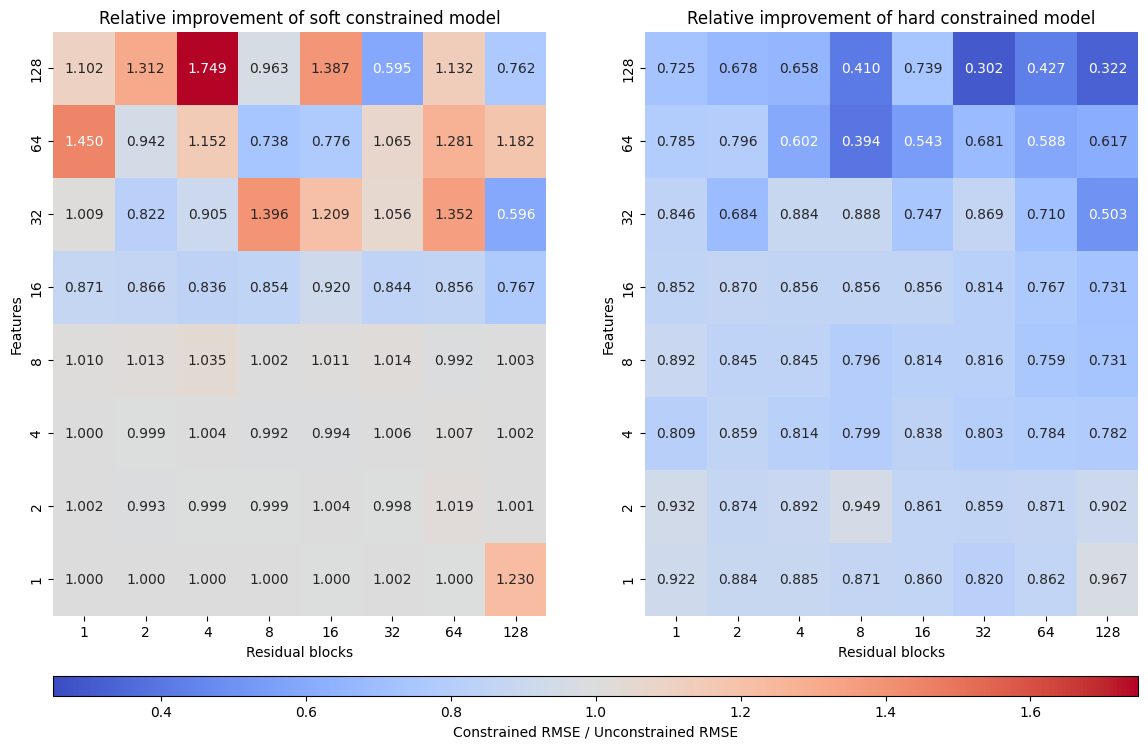

In [24]:
soft_diff = rmses[1] / rmses[0]
hard_diff = rmses[2] / rmses[0]

diffs = np.stack([soft_diff, hard_diff])

fig, axs = plt.subplots(nrows=1, ncols=2, figsize = (14,8))

abs_max = np.abs(diffs - 1).max()

titles = ['Relative improvement of soft constrained model', 'Relative improvement of hard constrained model']
for i in range(2):
    axs[i].set_title(titles[i])
    sns.heatmap(diffs[i],
                xticklabels=sorted(data['residual_blocks'].unique()),
                yticklabels=sorted(data['features'].unique()),
                fmt='.3f', annot=True,
                vmin=1 - abs_max, vmax= 1 + abs_max, cbar = False,
                cmap='coolwarm', ax=axs[i])
    axs[i].set_xlabel('Residual blocks')
    axs[i].set_ylabel('Features')
    axs[i].invert_yaxis()


fig.subplots_adjust(bottom=0.15)

left = axs[0].get_position().x0
width = axs[1].get_position().x1 - left

cbar_ax = fig.add_axes([left, 0.05, width, 0.025])
fig.colorbar(axs[0].collections[0], cax = cbar_ax, orientation='horizontal', label='Constrained RMSE / Unconstrained RMSE')

plt.show()

fig.savefig('images/sizes_rel_diff.pdf', bbox_inches='tight', dpi = 300)

In [25]:
def s(f, r):
    return 18 * f ** 2 * r + 153 * f ** 2 + 2 * f * r + 36 * f + 1

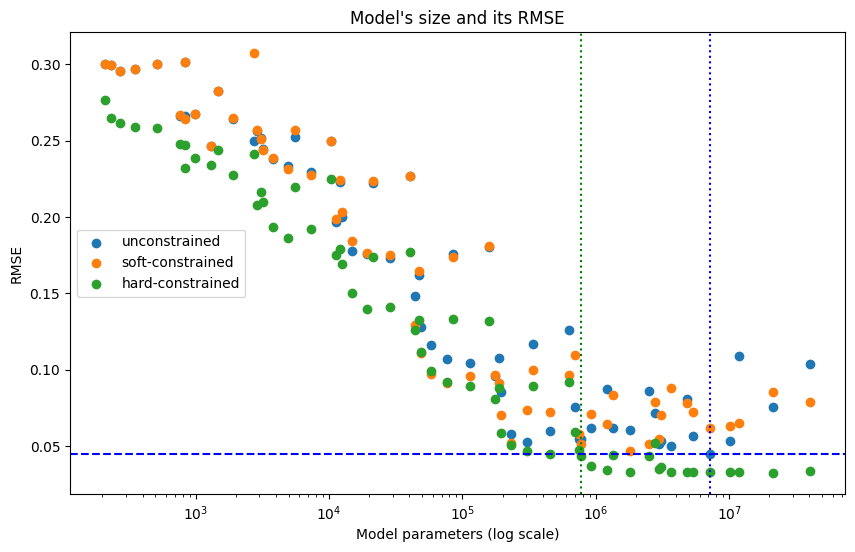

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize = (10,6))

group_names = {1 : 'unconstrained', 2 : 'soft-constrained', 12 : 'hard-constrained'}
for group in [1, 2, 12]:
    temp = data[data['group'] == group]
    ax.scatter(temp['parameters'], temp['rmse'], label=group_names[group])


ax.set_ylabel('RMSE')
ax.set_xlabel('Model parameters (log scale)')
ax.set_xscale('log')
ax.axvline(x=s(128, 16), linestyle=':', color='blue')
ax.axvline(x=s(64, 2), linestyle=':', color='green')
ax.axline(xy1=(s(64, 2), 0.04456), xy2=(s(64, 4), 0.04456), linestyle='--', color='blue')
ax.set_title('Model\'s size and its RMSE')
ax.legend()
plt.show()

fig.savefig('images/sizes_params.pdf', bbox_inches='tight', dpi = 300)

## Training stability

In [27]:
data_unc = pd.read_csv('val_rmse_v412.csv')
data_hard = pd.read_csv('val_rmse_v455.csv')
data_soft = pd.read_csv('val_rmse_v533.csv')

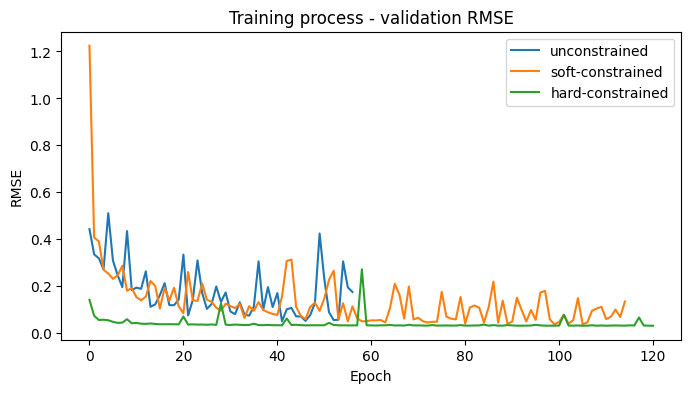

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(data_unc['Value'], label='unconstrained')
ax.plot(data_soft['Value'], label='soft-constrained')
ax.plot(data_hard['Value'], label='hard-constrained')
ax.legend()
ax.set_ylabel('RMSE')
ax.set_xlabel('Epoch')
ax.set_title('Training process - validation RMSE')
plt.show()

fig.savefig('images/validation_rmse.pdf', bbox_inches='tight', dpi = 300)